<a href="https://colab.research.google.com/github/VaneCamposGuzman/6F_Proyecto_Deteccion_Cancer_Piel/blob/main/Copia_de_train_yolov8_object_detection_on_custom_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
# Pip install method (recommended)

!pip install ultralytics==8.2.103 -q

from IPython import display
display.clear_output()

# prevent ultralytics from tracking your activity
!yolo settings sync=False

import ultralytics
ultralytics.checks()

Ultralytics YOLOv8.2.103 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 47.4/112.6 GB disk)


In [19]:
from ultralytics import YOLO

from IPython.display import display, Image

In [5]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="2muEGheN4U3QqQeyhYam")
project = rf.workspace("a23310324-live-ceti-mx").project("skin-cancer-s8wu9-p5ufh")
version = project.version(1)
dataset = version.download("yolov8")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Skin-Cancer-1 in yolov8:: 100%|██████████| 2445/2445 [00:00<00:00, 12364.88it/s]


In [6]:
%cd {HOME}

!yolo task=detect mode=train model=yolov8s.pt data={dataset.location}/data.yaml epochs=25 imgsz=640 plots=True

/content
100% 21.5M/21.5M [00:00<00:00, 118MB/s] 
New https://pypi.org/project/ultralytics/8.4.71 available 😃 Update with 'pip install -U ultralytics'
Ultralytics YOLOv8.2.103 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: task=detect, mode=train, model=yolov8s.pt, data=/content/datasets/Skin-Cancer-1/data.yaml, epochs=25, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=train, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False

In [9]:
from IPython.display import Image, display

/content


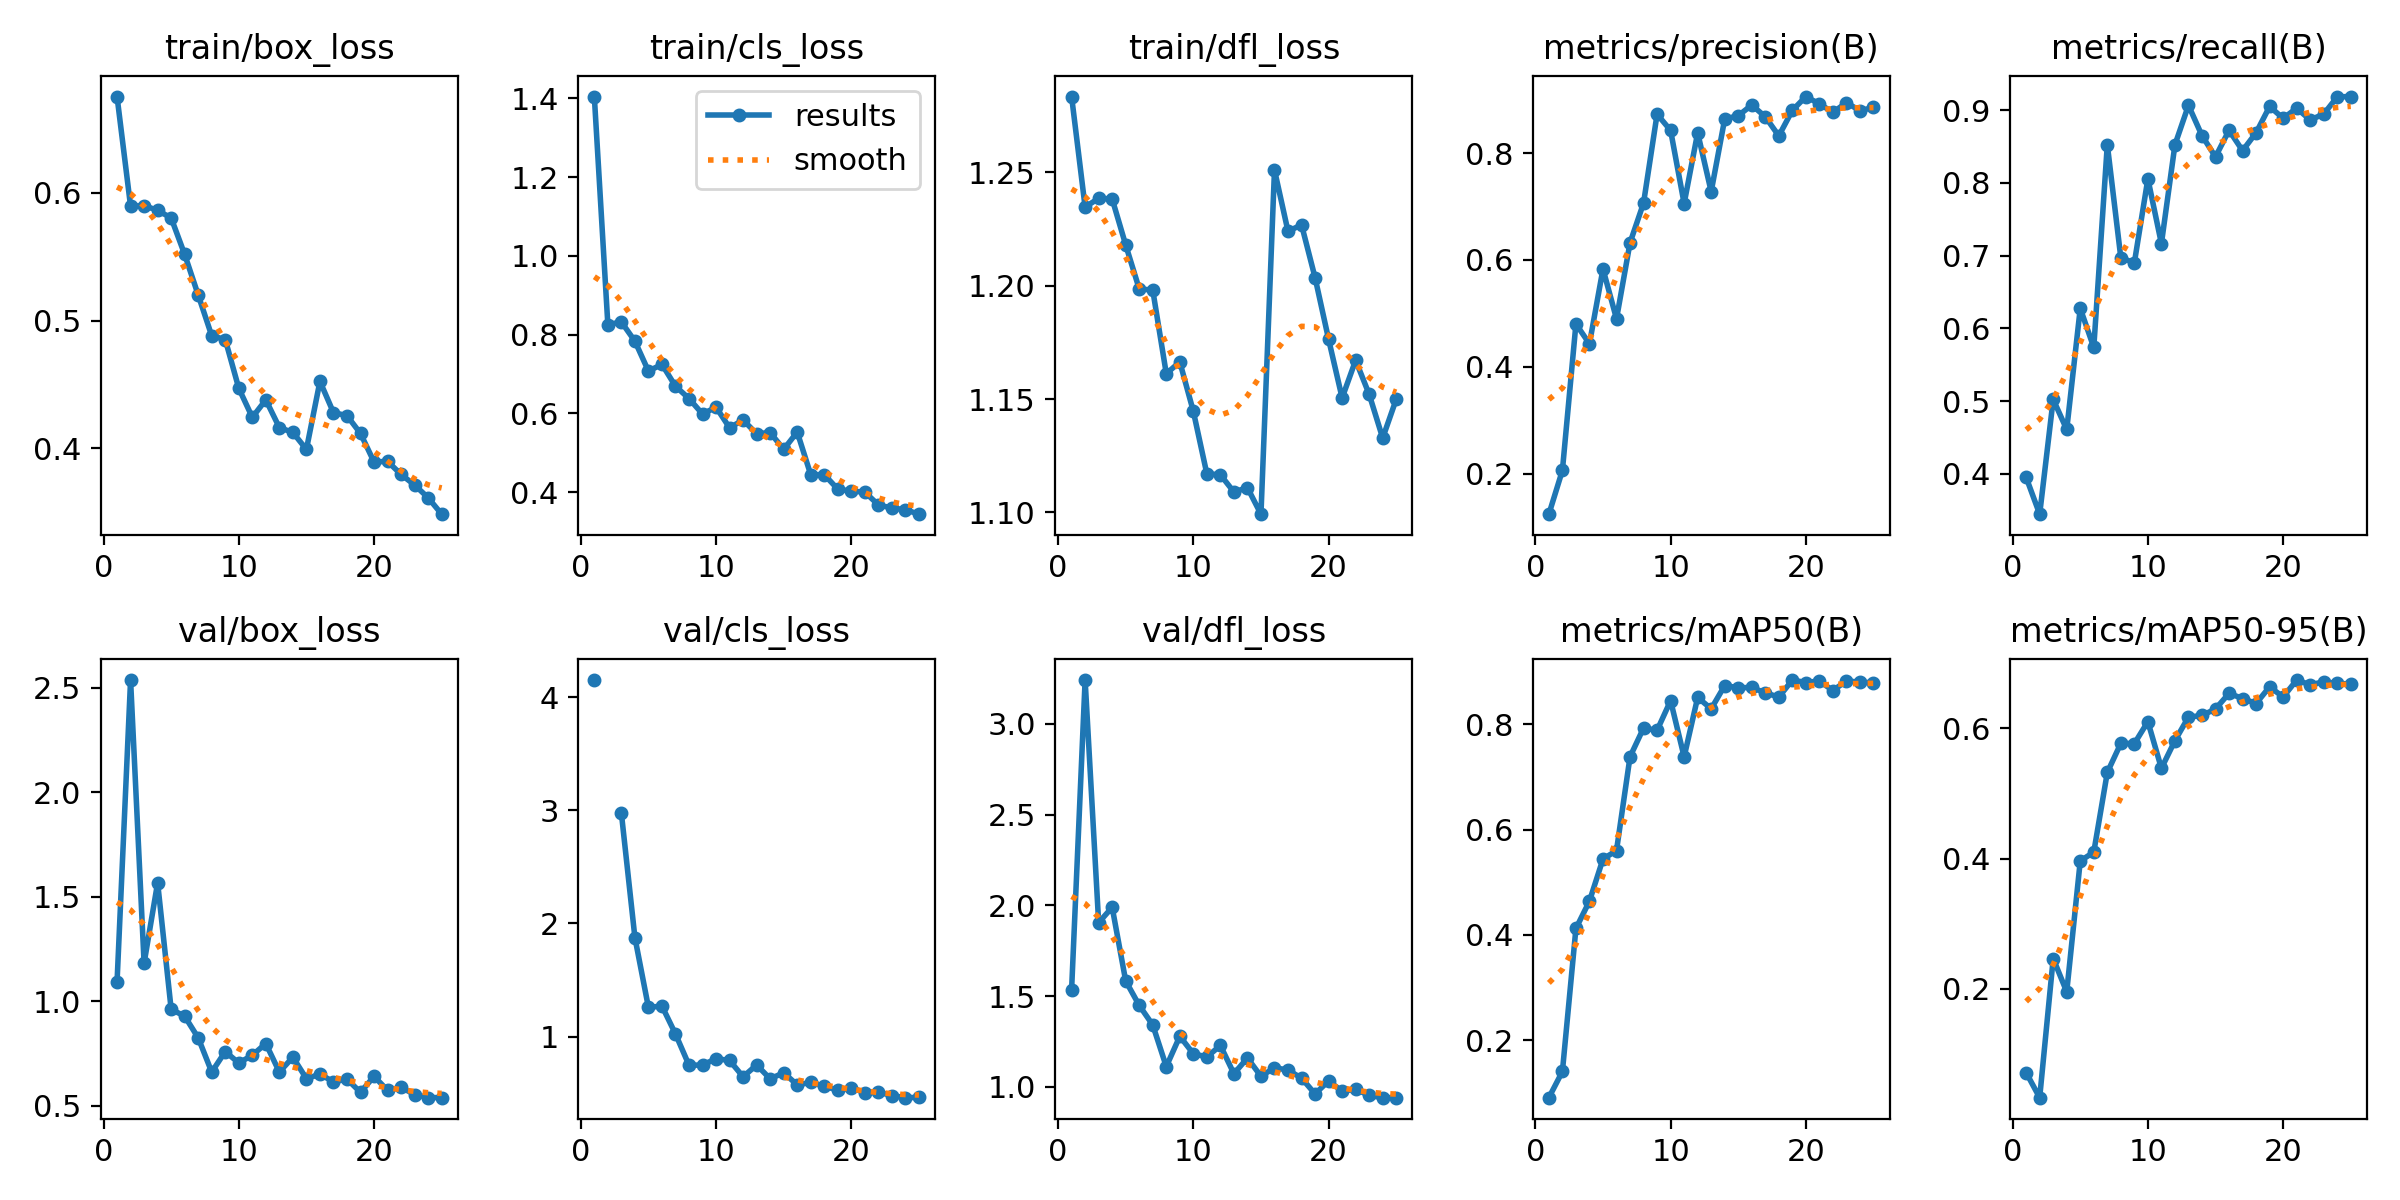

In [15]:
%cd {HOME}
Image(filename=f'{HOME}/runs/detect/train/results.png', width=600)

/content


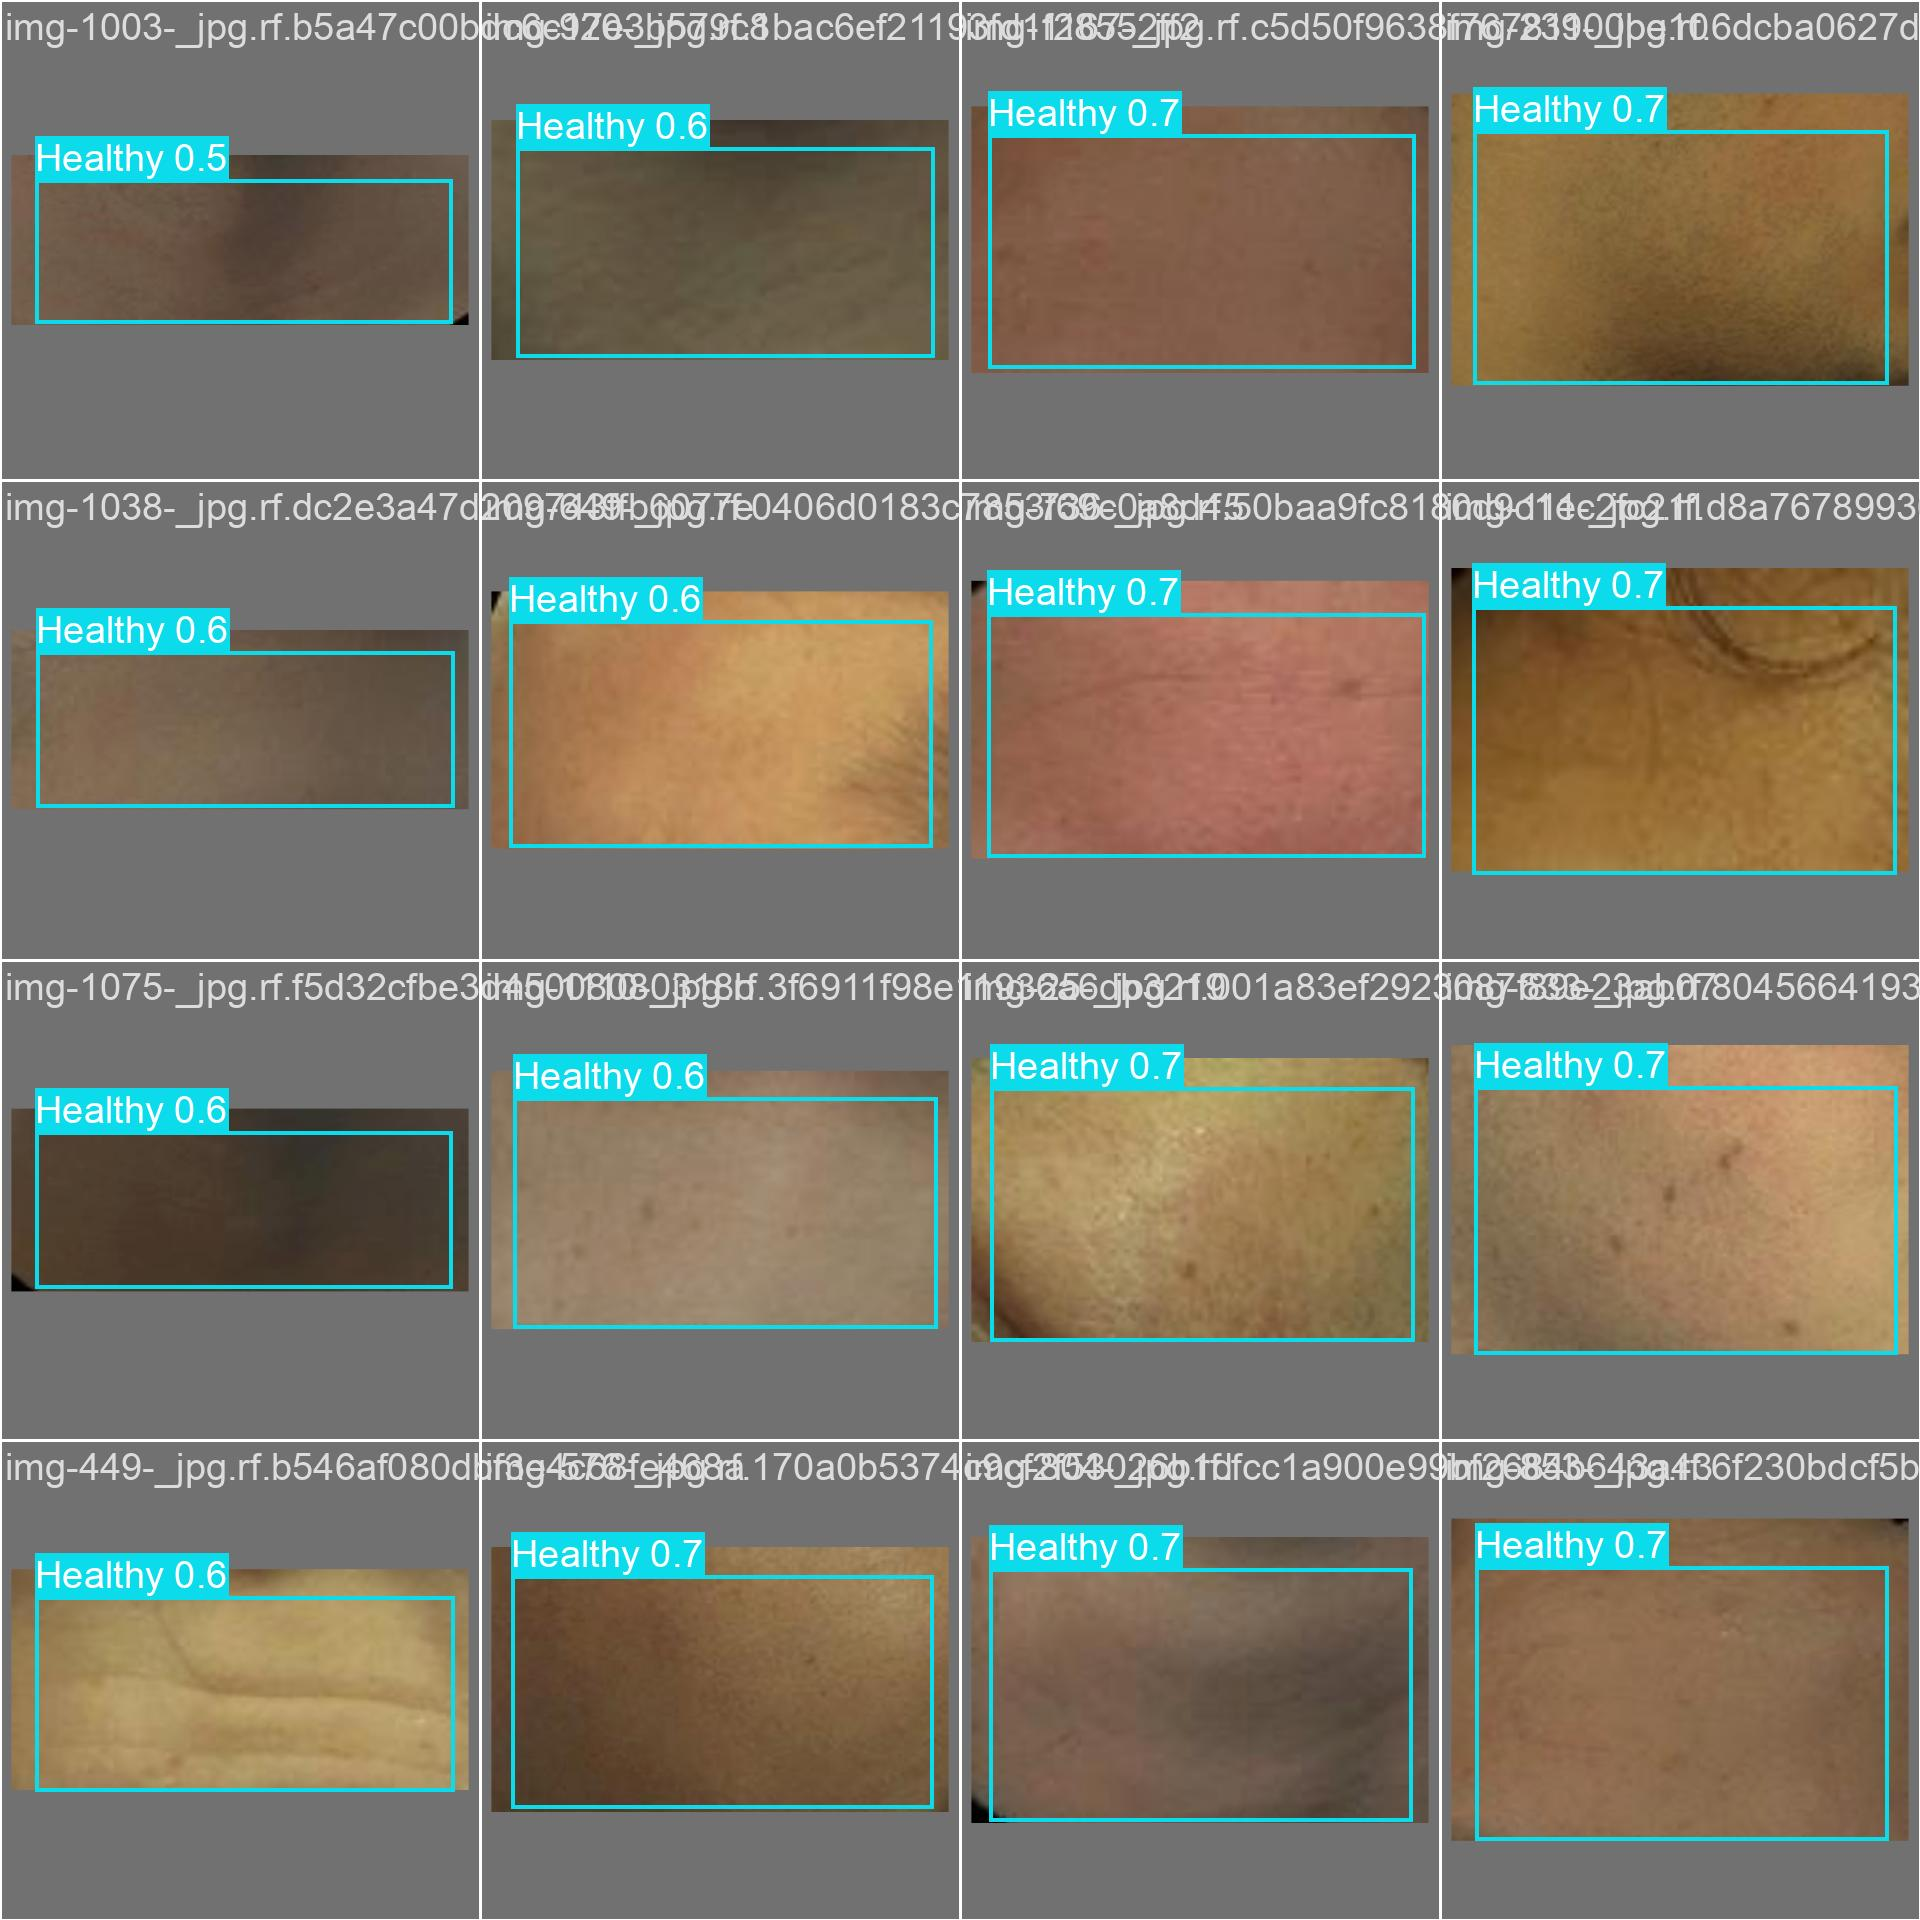

In [20]:
%cd {HOME}
Image(filename=f'{HOME}/runs/detect/train/val_batch0_pred.jpg', width=600)

## Validate Custom Model

In [16]:
!yolo task=detect mode=val model={HOME}/runs/detect/train/weights/best.pt data={dataset.location}/data.yaml

Ultralytics YOLOv8.2.103 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 168 layers, 11,126,358 parameters, 0 gradients, 28.4 GFLOPs
val: Scanning /content/datasets/Skin-Cancer-1/valid/labels.cache... 244 images, 0 backgrounds, 0 corrupt: 100% 244/244 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% 16/16 [00:04<00:00,  3.75it/s]
                   all        244        325      0.893      0.903      0.884      0.674
                Benign        200        280      0.904       0.94      0.974       0.93
               Healthy         44         45      0.882      0.867      0.793      0.418
Speed: 1.1ms preprocess, 8.7ms inference, 0.0ms loss, 1.6ms postprocess per image
Results saved to runs/detect/val3
💡 Learn more at https://docs.ultralytics.com/modes/val


## Inference with Custom Model

In [12]:
!yolo task=detect mode=predict model={HOME}/runs/detect/train/weights/best.pt conf=0.25 source={dataset.location}/test/images save=True

Ultralytics YOLOv8.2.103 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 168 layers, 11,126,358 parameters, 0 gradients, 28.4 GFLOPs

image 1/122 /content/datasets/Skin-Cancer-1/test/images/1000_jpg.rf.21b67857c8566e154932d97b892b2999.jpg: 640x640 2 Benigns, 10.9ms
image 2/122 /content/datasets/Skin-Cancer-1/test/images/1004_jpg.rf.55bda07bdb11a7d7a2a8762334b3e1a7.jpg: 640x640 1 Benign, 16.3ms
image 3/122 /content/datasets/Skin-Cancer-1/test/images/1020_jpg.rf.c48a6ace911a41f174b8de33938cf62a.jpg: 640x640 2 Benigns, 16.2ms
image 4/122 /content/datasets/Skin-Cancer-1/test/images/104_jpg.rf.ac4c68a44855b45ddeee1dffc433580f.jpg: 640x640 1 Benign, 16.2ms
image 5/122 /content/datasets/Skin-Cancer-1/test/images/1081_jpg.rf.906e78083407decf4461663674ea9041.jpg: 640x640 1 Benign, 16.1ms
image 6/122 /content/datasets/Skin-Cancer-1/test/images/1117_jpg.rf.d6a043f4e97b2a45944b6465834090d1.jpg: 640x640 1 Benign, 16.1ms
image 7/122 /content/datasets/Skin-Cance

**NOTE:** Let's take a look at few results.

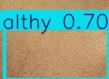

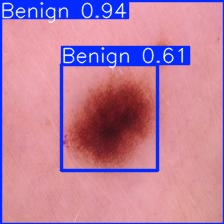

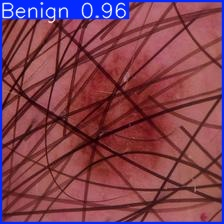

In [23]:
import glob
from IPython.display import Image, display

# Define the base path where the folders are located
base_path = '/content/runs/detect/'

# List all directories that start with 'predict' in the base path
subfolders = [os.path.join(base_path, d) for d in os.listdir(base_path)
              if os.path.isdir(os.path.join(base_path, d)) and d.startswith('predict')]

# Find the latest folder by modification time
latest_folder = max(subfolders, key=os.path.getmtime)

image_paths = glob.glob(f'{latest_folder}/*.jpg')[:3]

# Toma las primeras 3 imágenes de esa carpeta y las muestra
for image_path in image_paths:
    display(Image(filename=image_path, width=600))
    print("\n")

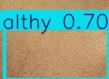

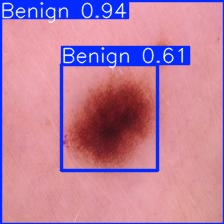

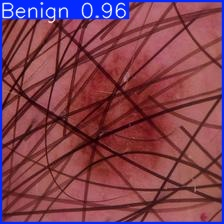

In [22]:
import glob
from IPython.display import Image, display

# Esto busca la última carpeta de predicciones que se haya creado
latest_predict = max(glob.glob('/content/runs/detect/predict*'), key=os.path.getmtime)

# Toma las primeras 3 imágenes de esa carpeta y las muestra
for image_path in glob.glob(f'{latest_predict}/*.png')[:3] + glob.glob(f'{latest_predict}/*.jpg')[:3]:
    display(Image(filename=image_path, width=600))
    print("\n")